In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [3]:
class BatsmenState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_percent: float
    summary: str

In [11]:
def calculate_sr(state: BatsmenState):
    sr = (state['runs']/state['balls'])/100

    state['sr'] = sr

    return {'sr': sr}

In [12]:
def calculate_bpb(state: BatsmenState):
    bpb = state['balls']/(state['fours'] + state['sixes'])

    state['bpb'] = bpb

    return {'bpb': bpb}

In [13]:
def calculate_boundary_percent(state: BatsmenState):
    boundary_percent = (((state['fours'] + 4) * (state['sixes'] * 6))/state['runs'])*100

    state['boundary_percent'] = boundary_percent

    return {'boundary_percent': boundary_percent}

In [14]:
def summary(state: BatsmenState):
    summary = f"""
Strike Rate - {state['sr']}\ng
Balls per boundary - {state['bpb']} \n
Boundary Percent - {state['boundary_percent']}
"""

    state['summary'] = summary

    return {'summary': summary}

In [15]:
graph = StateGraph(BatsmenState)

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('summary', summary)

graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_percent')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundary_percent', 'summary')

graph.add_edge('summary', END)

workflow = graph.compile()


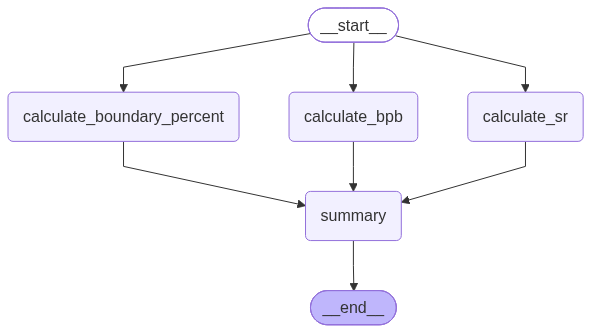

In [16]:
workflow

In [18]:
initial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

output_state = workflow.invoke(initial_state)
print(output_state)


{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 0.02, 'bpb': 5.0, 'boundary_percent': 240.0, 'summary': '\nStrike Rate - 0.02\ng\nBalls per boundary - 5.0 \n\nBoundary Percent - 240.0\n'}
